# Dynamic Networks

In this notebook, we examine methods for processing an undirected **dynamic network** using two distinct **time window** construction strategies. 

In [6]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

## Time Window Network Construction 1

For this example, we use a CSV file containing timestamped interactions between pairs of individuals. Each timestamp corresponds to the specific day of the year when the interaction occurred. This approach could be used to track the evolution of social relationships over time.

In [7]:
df = pd.read_csv("interactions.csv", sep=",")
print(f"Total of {len(df)} interactions over time")
df.head(10)

Total of 401 interactions over time


,day,person1,person2
0,3,Daniel,Emma
1,3,Emma,Oscar
2,4,Emily,Emma
3,4,Alex,Mia
4,6,Jacob,Madison
5,7,Mason,Sophia
6,8,Harry,Noah
7,8,Madison,Oscar
8,9,Mason,Olivia
9,11,Daniel,Noah


We can examine the range of timestamps to understand the temporal scope of our dataset:

In [8]:
min_day = df["day"].min()
max_day = df["day"].max()
print(f"Day range: {min_day} to {max_day}")

Day range: 3 to 359


Let's divide the data into 5 time windows of approximately equal duration. This equal division approach ensures balanced representation across temporal periods.

In [9]:
num_windows = 5

We can then calculate the duration of each window (i.e. the number of days for each interval):

In [10]:
# round up to the nearest full day
window_size = round(365/num_windows)
print(f"Window size: {window_size} days")

Window size: 73 days


Now we will split our original DataFrame into a series of frames, one per time window. This allows us to analyse network properties in each period.

In [11]:
window_frames = []
current_min = 1
for window_number in range(1, num_windows+1):
    # set the current window range
    win_min = current_min
    win_max = win_min + window_size
    # handle the last window correctly, so we don't lose data
    if window_number == num_windows:
        wf = df[(df["day"]>=win_min) & (df["day"]<=win_max)]
    else:
        # otherwise we exclude the last day
        wf = df[(df["day"]>=win_min) & (df["day"]<win_max)]
    window_frames.append(wf)
    print(f"Window {window_number}: Day {win_min} to {win_max-1} -> {len(wf)} interactions")
    # increment
    current_min += window_size

Window 1: Day 1 to 73 -> 76 interactions
Window 2: Day 74 to 146 -> 92 interactions
Window 3: Day 147 to 219 -> 80 interactions
Window 4: Day 220 to 292 -> 83 interactions
Window 5: Day 293 to 365 -> 70 interactions


In [12]:
# check each of the DataFrames
for wf in window_frames:
    print(wf.head(3))
    print()

   day person1 person2
0    3  Daniel    Emma
1    3    Emma   Oscar
2    4   Emily    Emma

    day person1  person2
76   74    Emma  Madison
77   74     Mia   Sophia
78   75  Daniel    Mason

     day  person1 person2
168  148  Madison  Sophia
169  148     Alex  Sophia
170  149     Alex    Noah

     day person1 person2
248  220  Daniel   Oscar
249  220    Alex   Harry
250  220   Harry     Mia

     day person1 person2
331  294  Olivia  Sophia
332  296  Daniel   Oscar
333  297   Mason    Noah



Create an undirected network for each time window using the `nx.from_pandas_edgelist()` function:

In [13]:
window_networks = []
for w in range(num_windows):
    # create the directed network from the corresponding DataFrame
    g = nx.from_pandas_edgelist(window_frames[w], "person1", "person2")  
    print(f"Window {w+1} network has {g.number_of_nodes()} nodes, {g.number_of_edges()} edges")
    window_networks.append(g)

Window 1 network has 15 nodes, 52 edges
Window 2 network has 15 nodes, 60 edges
Window 3 network has 15 nodes, 57 edges
Window 4 network has 15 nodes, 56 edges
Window 5 network has 16 nodes, 56 edges


We can visualise the first window network to observe the structure of relationships during this period:

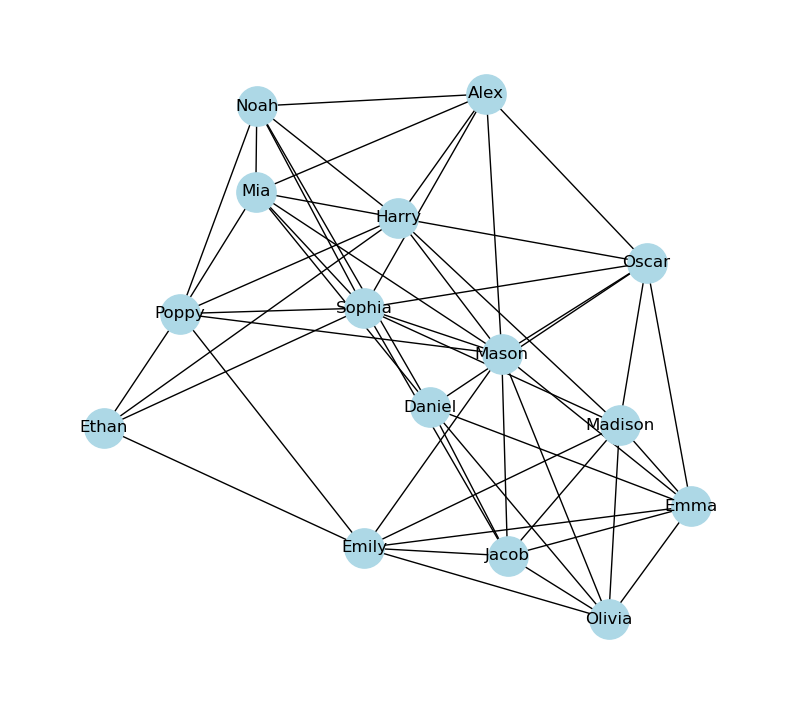

In [14]:
plt.figure(figsize=(10, 9))
plt.margins(0.1, 0.1)
# layout and draw the 1st network
pos = nx.spring_layout(window_networks[0])
nx.draw_networkx(window_networks[0], pos, 
                 with_labels=True, 
                 font_size=12, 
                 node_size=800, 
                 node_color="lightblue")
plt.axis("off")
plt.show()

Visualise the second window network to compare structural changes over time:

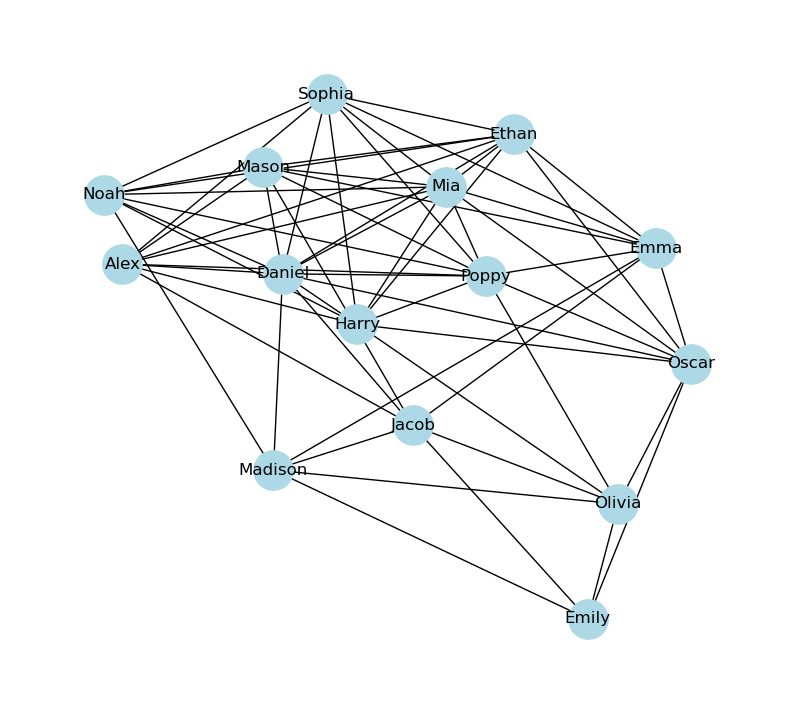

In [15]:
plt.figure(figsize=(10, 9))
plt.margins(0.1, 0.1)
# layout and draw the 2nd network
pos = nx.spring_layout(window_networks[1])
nx.draw_networkx(window_networks[1], pos, 
                 with_labels=True, 
                 font_size=12, 
                 node_size=800, 
                 node_color="lightblue")
plt.axis("off")
plt.show()

For each window network, we can measure various structural characteristics, such as its **density** - i.e. how interconnected the nodes are in each time period:

In [16]:
for i, g in enumerate(window_networks):
    print(f"Window network {i+1}: density={nx.density(g):.3f}")

Window network 1: density=0.495
Window network 2: density=0.571
Window network 3: density=0.543
Window network 4: density=0.533
Window network 5: density=0.467


We can also identify the most central nodes in each network by examining degree centrality:

In [17]:
for i, g in enumerate(window_networks):
    degrees = dict(g.degree())
    # sort by degree in descending order
    s_deg = pd.Series(degrees).sort_values(ascending=False)
    # get the top ranked node 
    most_central_node = s_deg.index[0]
    print(f"Window network {i+1}: {most_central_node}")

Window network 1: Mason
Window network 2: Daniel
Window network 3: Poppy
Window network 4: Noah
Window network 5: Noah


## Time Window Network Construction 2

Rather than prespecifying a fixed number of windows, we might prefer to divide the data by setting a fixed duration for each window. 

In this example, we specifiy a window duration of 30 days.

In [18]:
window_size = 30

Construct the window DataFrames using this fixed duration:

In [19]:
window_frames = []
window_number = 0
current_min = 1
while True:
    window_number += 1
    # set the current window range
    win_min = current_min
    win_max = win_min + window_size
    # notice we exclude the last day
    wf = df[(df["day"]>=win_min) & (df["day"]<win_max)]
    window_frames.append(wf)
    print(f"Window {window_number}: Day {win_min} to {win_max-1} -> {len(wf)} interactions")
    # increment
    current_min += window_size
    # are we finished?
    if current_min > max_day:
        break

Window 1: Day 1 to 30 -> 33 interactions
Window 2: Day 31 to 60 -> 26 interactions
Window 3: Day 61 to 90 -> 39 interactions
Window 4: Day 91 to 120 -> 43 interactions
Window 5: Day 121 to 150 -> 31 interactions
Window 6: Day 151 to 180 -> 33 interactions
Window 7: Day 181 to 210 -> 33 interactions
Window 8: Day 211 to 240 -> 37 interactions
Window 9: Day 241 to 270 -> 37 interactions
Window 10: Day 271 to 300 -> 23 interactions
Window 11: Day 301 to 330 -> 29 interactions
Window 12: Day 331 to 360 -> 37 interactions


Again, we can create an undirected network for each time window and examine their structural properties:

In [20]:
rows = []
for w, df_win in enumerate(window_frames):
    # create the directed network from the corresponding DataFrame
    g = nx.from_pandas_edgelist(df_win, "person1", "person2")  
    print(f"Window {w+1} network has {g.number_of_nodes()} nodes, {g.number_of_edges()} edges")
    rows.append({"Window": (w+1), 
                "Nodes": g.number_of_nodes(), "Edges": g.number_of_edges()})

Window 1 network has 15 nodes, 30 edges
Window 2 network has 14 nodes, 23 edges
Window 3 network has 15 nodes, 32 edges
Window 4 network has 15 nodes, 37 edges
Window 5 network has 14 nodes, 25 edges
Window 6 network has 15 nodes, 29 edges
Window 7 network has 15 nodes, 29 edges
Window 8 network has 15 nodes, 28 edges
Window 9 network has 15 nodes, 32 edges
Window 10 network has 14 nodes, 20 edges
Window 11 network has 15 nodes, 25 edges
Window 12 network has 16 nodes, 35 edges


As an example, we can visualise the new first window network to observe differences from the previous windowing approach:

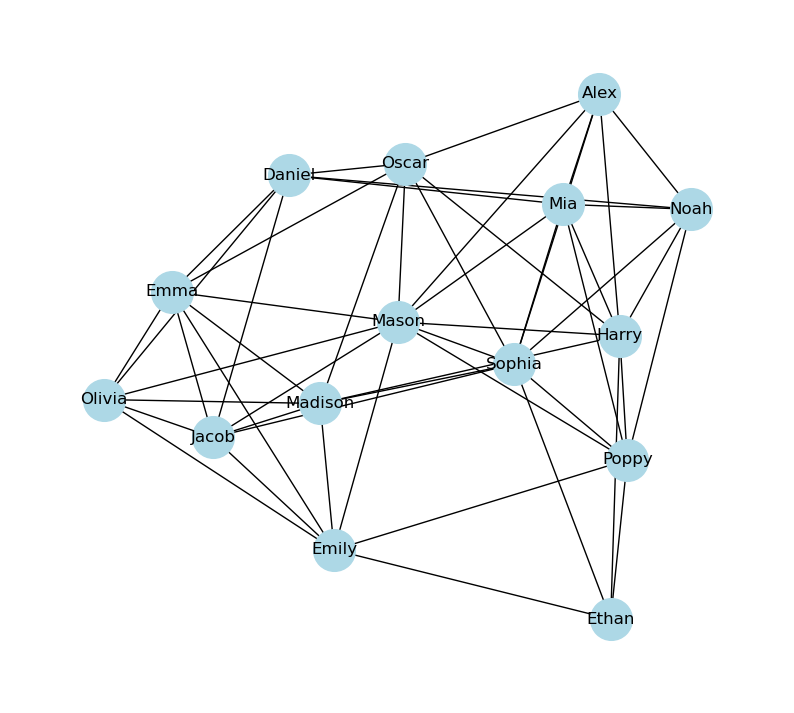

In [21]:
plt.figure(figsize=(10, 9))
plt.margins(0.1, 0.1)
pos = nx.spring_layout(window_networks[0])
# layout and draw the 1st network
nx.draw_networkx(window_networks[0], pos, 
                 with_labels=True, 
                 font_size=12, 
                 node_size=900, 
                 node_color="lightblue")
plt.axis("off")
plt.show()

We can also plot the number of nodes and edges in each time window network to observe temporal changes in network structure:

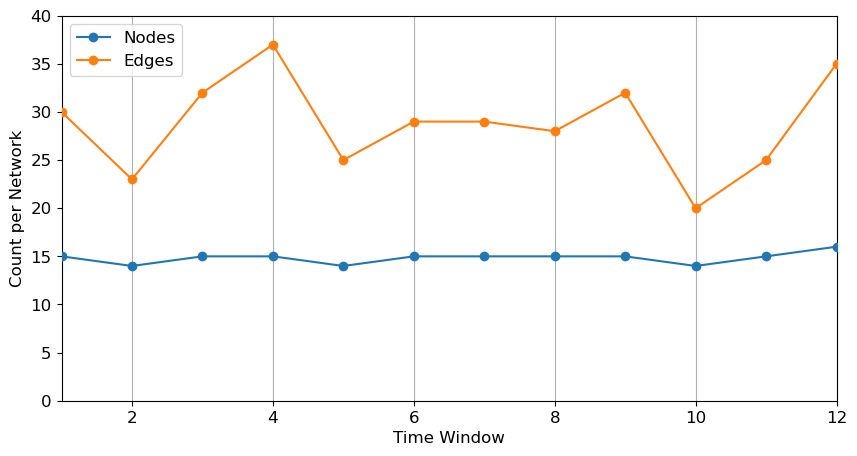

In [22]:
df = pd.DataFrame(rows).set_index("Window")
ax = df.plot(figsize=(10, 5), style=".-", ms=12, fontsize=12, zorder=3)
ax.set_xlabel("Time Window", fontsize=12)
ax.set_ylabel("Count per Network", fontsize=12)
ax.xaxis.grid()
ax.legend(fontsize=12)
# adjust the axes
ax.set_ylim(0, 40)
ax.set_xlim(1, len(window_frames))
plt.show()